Q.1 : Outlier Detection using the Percentile Method

Theory Recap:
- Instead of Z-score or IQR, we directly use percentile cut-offs.
- Example:
- Drop values below the Ist percentile
- Drop values above the 99th percentile
- Useful when data is skewed or not normally distributed.

Tasks:
- Generate 1000 income values from a skewed distribution (log-normal).
- Introduce 5 extreme values (very high incomes).
- Compute Ist and 99th percentiles.
- Remove values outside this range.
- Plot histograms before and after outlier removal.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
np.random.seed(42)

# Generate skewed income data (log-normal)
income = np.random.lognormal(mean=10, sigma=0.8, size=1000).astype(int)

df = pd.DataFrame({'Income': income})

print(df.head())

print("Shape Before adding outliers:", df.shape)

   Income
0   32773
1   19719
2   36980
3   74490
4   18263
Shape Before adding outliers: (1000, 1)


In [6]:
outliers = pd.DataFrame({
    'Income': [500000, 800000, 1000000, 1200000, 1500000]
})

df = pd.concat([df, outliers], ignore_index=True)

print(df.tail())
print("Shape after adding outliers:", df.shape)

       Income
1000   500000
1001   800000
1002  1000000
1003  1200000
1004  1500000
Shape after adding outliers: (1005, 1)


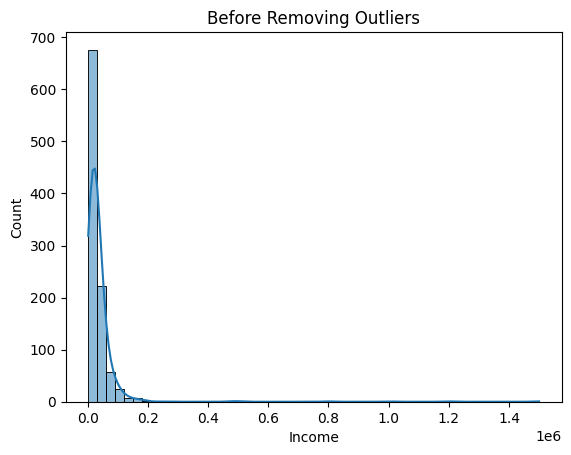

In [7]:
plt.figure()
sns.histplot(df['Income'], bins=50, kde=True)
plt.title("Before Removing Outliers")
plt.show()

In [9]:
p1 = np.percentile(df['Income'], 1)
p99 = np.percentile(df['Income'], 99)

print("1st percentile:", p1)
print("99th percentile:", p99)

df_clean = df[(df['Income'] >= p1) & (df['Income'] <= p99)]

print("Before:", df.shape)
print("After:", df_clean.shape)

1st percentile: 4165.16
99th percentile: 170590.20000000016
Before: (1005, 1)
After: (983, 1)


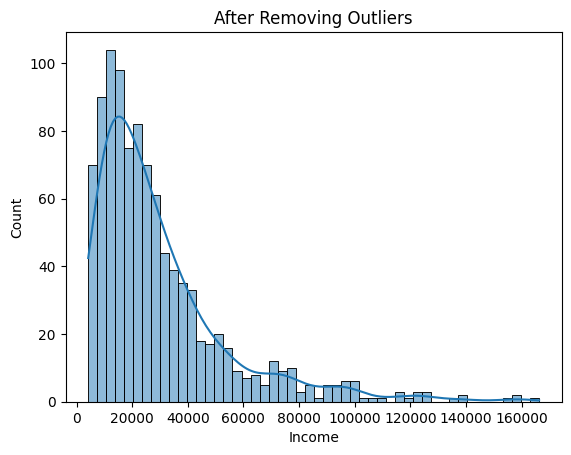

In [10]:
plt.figure()
sns.histplot(df_clean['Income'], bins=50, kde=True)
plt.title("After Removing Outliers")
plt.show()

In [11]:
print("Mean before:", df['Income'].mean())
print("Mean after:", df_clean['Income'].mean())

Mean before: 35543.03482587064
Mean after: 29733.911495422177


Q.2 : Percentile Method with Different Thresholds

Objective: Explore how varying percentile cut-offs changes outlier detection.

Steps:
- Use the same skewed income dataset.
- Apply percentile-based filtering with:
- (1st, 99th)
- (5th, 95th)
- (10th, 90th)

For each case, compute dataset size, mean, and standard deviation.
- Plot side-by-side histograms showing the effect of stricter vs looser cut-offs.

In [28]:
#P1 
p1 = np.percentile(df['Income'], 1)
p99 = np.percentile(df['Income'], 99)

df_1 = df[(df['Income']>= p1) & (df['Income']<= p99)]

print("P1")
print("Before:", df.shape)
print("After:", df_1.shape)
print("Mean Before:", df["Income"].mean())
print("Mean After:", df_1["Income"].mean())
print("Stanbdard Deviation Before:", df["Income"].std())
print("Standard Deviation After:", df_1["Income"].std(), "\n")

#P5
p5 = np.percentile(df['Income'], 5)
p95 = np.percentile(df['Income'], 95)

df_5 = df[(df['Income']>= p5) & (df['Income']<= p95)]

print("P5")
print("Before:", df.shape)
print("After:", df_5.shape)
print("Mean Before:", df["Income"].mean())
print("Mean After:", df_5["Income"].mean())
print("Stanbdard Deviation Before:", df["Income"].std())
print("Standard Deviation After:", df_5["Income"].std(), "\n")

#P10 
p10 = np.percentile(df['Income'], 10)
p90 = np.percentile(df['Income'], 90)

df_10 = df[(df["Income"]>= p10) & (df["Income"]<= p90)]

print("P10")
print("Before:", df.shape)
print("After:", df_10.shape)
print("Mean Before:", df["Income"].mean())
print("Mean After:", df_10["Income"].mean())
print("Stanbdard Deviation Before:", df["Income"].std())
print("Standard Deviation After:", df_10["Income"].std(), "\n")

P1
Before: (1005, 1)
After: (983, 1)
Mean Before: 35543.03482587064
Mean After: 29733.911495422177
Stanbdard Deviation Before: 78604.81357013829
Standard Deviation After: 24654.842145040053 

P5
Before: (1005, 1)
After: (903, 1)
Mean Before: 35543.03482587064
Mean After: 27151.891472868218
Stanbdard Deviation Before: 78604.81357013829
Standard Deviation After: 17497.581735586504 

P10
Before: (1005, 1)
After: (803, 1)
Mean Before: 35543.03482587064
Mean After: 25417.753424657534
Stanbdard Deviation Before: 78604.81357013829
Standard Deviation After: 13139.666503641 



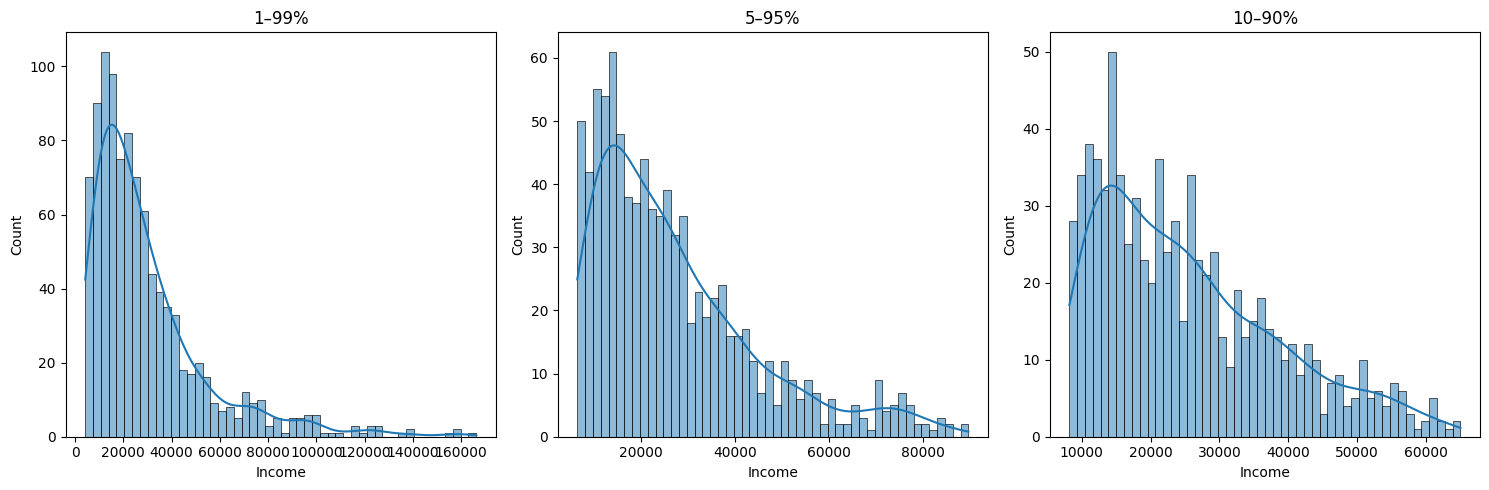

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

# Plot 1: 1–99%
plt.subplot(1, 3, 1)
sns.histplot(df_1['Income'], bins=50, kde=True)
plt.title("1–99%")

# Plot 2: 5–95%
plt.subplot(1, 3, 2)
sns.histplot(df_5['Income'], bins=50, kde=True)
plt.title("5–95%")

# Plot 3: 10–90%
plt.subplot(1, 3, 3)
sns.histplot(df_10['Income'], bins=50, kde=True)
plt.title("10–90%")

plt.tight_layout()
plt.show()

Q.3 : Winsorization Technique

Theory Recap:
- Instead of removing outliers, Winsorization caps them to the nearest threshold.
- Example:
- Values below 5th percentile → set to 5th percentile
- Values above 95th percentile → set to 95th percentile
- Preserves dataset size while reducing outlier impact.

Tasks:
- Use the same income dataset from Task 1.
- Apply Winsorization with Sth and 95th percentile limits.
- Compare mean, median, and standard deviation before vs after Winsorization.
- Plot boxplots before and after to visualize the effect.


Original Mean: 35543.03482587064
Winsorized Mean: 29277.886965174133 

Original Shape: (1005, 1)
Winsorized Shape: (1005, 1)


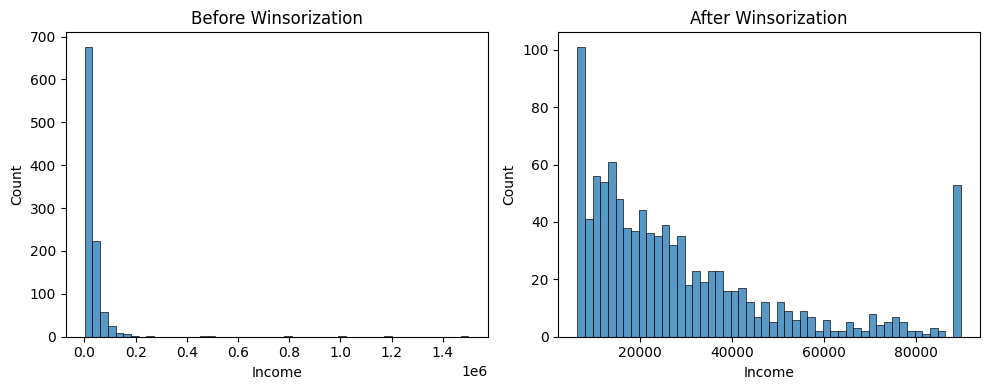

In [40]:
p5 = np.percentile(df['Income'], 5)
p95 = np.percentile(df['Income'], 95)

df_win = df.copy()

df_win['Income'] = df_win['Income'].clip(lower=p5, upper=p95)

print("Original Mean:", df['Income'].mean())
print("Winsorized Mean:", df_win['Income'].mean(),"\n")

print("Original Shape:", df.shape)
print("Winsorized Shape:", df_win.shape)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Income'], bins=50)
plt.title("Before Winsorization")

plt.subplot(1,2,2)
sns.histplot(df_win['Income'], bins=50)
plt.title("After Winsorization")

plt.tight_layout()
plt.show()

Q.4 : Winsorization vs Z-score Removal

Objective: Compare Winsorization (capping) with Z-score (removal).

Steps: Take a dataset with extreme outliers (e.g., heights with some unrealistic
values).
- Handle outliers using:
- Z-score method (remove |Z| > 3)
- Winsorization (cap at 5th & 95th percentiles)
- Compare resulting dataset size, mean, and median across both methods.
- Plot boxnlots of orioinal. 7-score-cleaned. and Winsorized datasets.

=== ORIGINAL ===
Size: 205
Mean: 169.84613692515038
Median: 170.05113456642462

=== Z-SCORE CLEANED ===
Size: 200
Mean: 169.59229034827914
Median: 169.95808115952264

=== WINSORIZED ===
Size: 205
Mean: 169.64866451967157
Median: 170.05113456642462


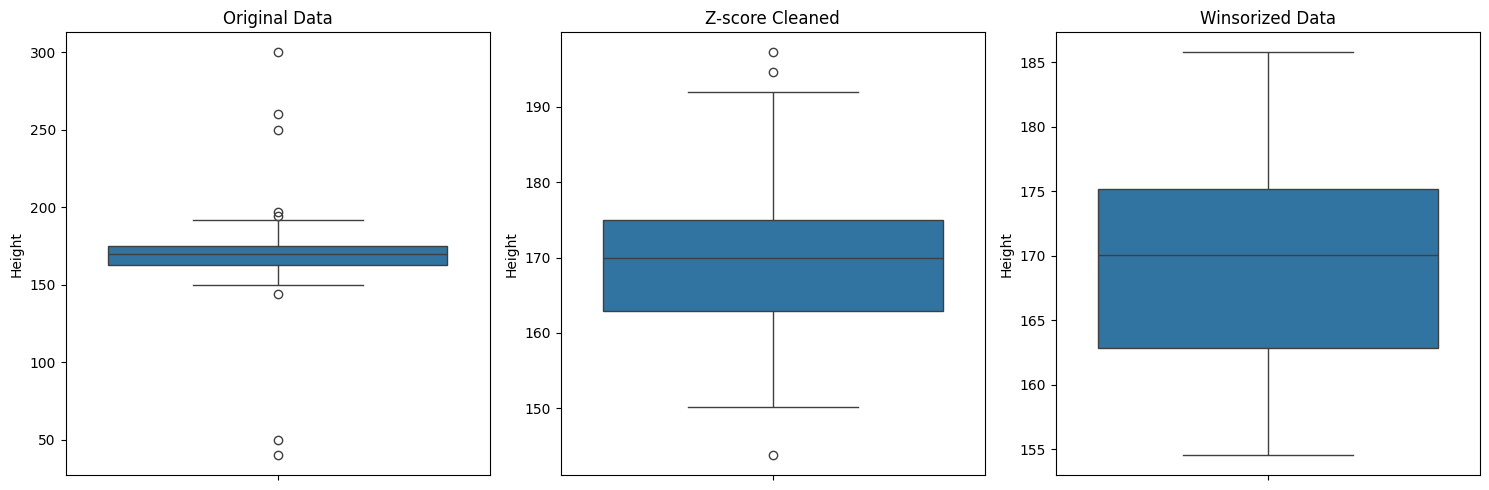

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Normal height data
heights = np.random.normal(loc=170, scale=10, size=200)

# Add unrealistic outliers
outliers = np.array([250, 260, 300, 50, 40])
heights = np.concatenate([heights, outliers])
df = pd.DataFrame({'Height': heights})



# Calculate Z-score
z = (df['Height'] - df['Height'].mean()) / df['Height'].std()

# Remove outliers
df_z = df[abs(z) < 3]

# Percentiles
p5 = np.percentile(df['Height'], 5)
p95 = np.percentile(df['Height'], 95)

# Apply capping
df_win = df.copy()
df_win['Height'] = df_win['Height'].clip(lower=p5, upper=p95)

print("=== ORIGINAL ===")
print("Size:", df.shape[0])
print("Mean:", df['Height'].mean())
print("Median:", df['Height'].median())

print("\n=== Z-SCORE CLEANED ===")
print("Size:", df_z.shape[0])
print("Mean:", df_z['Height'].mean())
print("Median:", df_z['Height'].median())

print("\n=== WINSORIZED ===")
print("Size:", df_win.shape[0])
print("Mean:", df_win['Height'].mean())
print("Median:", df_win['Height'].median())

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Height'])
plt.title("Original Data")

plt.subplot(1,3,2)
sns.boxplot(y=df_z['Height'])
plt.title("Z-score Cleaned")

plt.subplot(1,3,3)
sns.boxplot(y=df_win['Height'])
plt.title("Winsorized Data")

plt.tight_layout()
plt.show()